# Plot of all available Tanager images, known mining permits, and DRC boundaries

Just plot those three things to visualize coverage of the RS data relative to the mining industry in the region

In [8]:
# package imports
import os # for file path manipulation
import geopandas as gpd # for geospatial data manipulation
import matplotlib.pyplot as plt # for plotting
import pandas as pd # for data manipulation
import numpy as np # for numerical operations

In [21]:
# set up paths to data and load

base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/research/drc_hyperspectral'

# africa country boundaries
africa_boundaries_fp = os.path.join(base_path, 'misc_geospatial_files', 'africa_boundaries', 'Africa_Boundaries.shp')
africa_boundaries = gpd.read_file(africa_boundaries_fp)

# mining permits
mining_permits_fp = os.path.join(base_path, 'misc_geospatial_files', 'cobalt_permits_with_production.geojson')
mining_permits = gpd.read_file(mining_permits_fp)

# path to all tanager bounding boxes
tanager_bboxes_fp = os.path.join(base_path, 'processed_outputs', 'bounding_boxes')
# make a file list of all bounding boxes and read them in as a geodataframe
tanager_bboxes_files = [os.path.join(tanager_bboxes_fp, f) for f in os.listdir(tanager_bboxes_fp) if f.endswith('.geojson')]
tanager_bboxes = gpd.GeoDataFrame(pd.concat([gpd.read_file(f) for f in tanager_bboxes_files], ignore_index=True))

In [22]:
# Set them all to WGS84 epsg:4326
africa_boundaries = africa_boundaries.to_crs(epsg=4326)
mining_permits = mining_permits.to_crs(epsg=4326)
tanager_bboxes = tanager_bboxes.to_crs(epsg=4326)

/var/folders/gy/tnktbqnx0rv6k4vhfbk1m2hw0000gp/T/ipykernel_40925/3089876764.py:32: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/gy/tnktbqnx0rv6k4vhfbk1m2hw0000gp/T/ipykernel_40925/3089876764.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


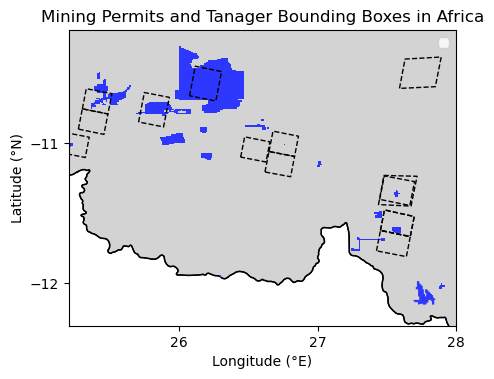

In [ ]:
# plot the data to check it looks correct

fig, ax = plt.subplots(figsize=(5, 5))

# plot the DRC in gray and Zambia in white
africa_boundaries[africa_boundaries['NAME_0'] == 'Democratic Republic of the Congo'].plot(ax=ax, color='lightgray', edgecolor='black')
africa_boundaries[africa_boundaries['NAME_0'] == 'Zambia'].plot(ax=ax, color='none', edgecolor='black')

# only plot permits where 
mining_permits.plot(ax=ax, color='#2e37fe', label='Mining Permits')

tanager_bboxes.plot(ax=ax, facecolor='none', edgecolor='black', linestyle='--', label='Tanager Bounding Boxes')

# set custom bounds for the map
long_min = 25.2
long_max = 28
lat_min = -12.3
lat_max = -10.2
ax.set_xlim(long_min, long_max)  # longitude bounds
ax.set_ylim(lat_min, lat_max)  # latitude bounds

# put ticks only on round degrees
x_ticks = np.arange(np.ceil(long_min), np.floor(long_max)+1, 1)
y_ticks = np.arange(np.ceil(lat_min), np.floor(lat_max)+1, 1)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# label axes
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.legend()
plt.title('Mining Permits and Tanager Bounding Boxes in Africa')
plt.show()

# prep fonts for pdf export
plt.rcParams['pdf.fonttype'] = 42

# save the figure as a pdf to downloads folder
output_fp = os.path.join(os.path.expanduser('~'), 'Downloads', 'katanga_coverage.pdf')
fig.savefig(output_fp, bbox_inches='tight')